# Fase 5b — Fine-tuning del modelo de embeddings generalista (E5)

Ajusta el modelo de embeddings multilingüe de propósito general `intfloat/multilingual-e5-base` sobre el corpus clínico, usando los tríos `(pregunta, positiva, negativa)` generados en la Fase 4b (`dataset_train_triplets.json`). El resultado es el modelo propio especializado (`./modelo_especializado_e5`) que se usa después como "modelo experto" en la Fase 5c.

1. **Entrenamiento con seguimiento de la pérdida** (celda 1): afina el modelo base con `MultipleNegativesRankingLoss` sobre los tríos (con los prefijos `query:`/`passage:` que exige E5), durante 3 épocas, batch size 28, lr 2e-5 y longitud máxima de secuencia 512, con semilla fija (42) para reproducibilidad. `MNRLossTracker` monitorea la función de pérdida para registrar el valor en cada paso de entrenamiento, lo que permite calcular y graficar la pérdida media por época (`curva_entrenamiento_e5.png`) como evidencia de la convergencia del modelo.
2. **Evaluación antes/después** (celda 2): sobre una muestra de 200 tríos, compara la distribución de similitud coseno pregunta-positiva frente a pregunta-negativa usando el modelo base y el modelo ya afinado. Los histogramas resultantes (`similitudes_antes_despues_ft.png`) muestran si el fine-tuning ha aumentado la separación entre contenido relevante e irrelevante.

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Pérdida media por época: [np.float64(1.433068335056305), np.float64(0.6485853694580697), np.float64(0.4359490935866897)]


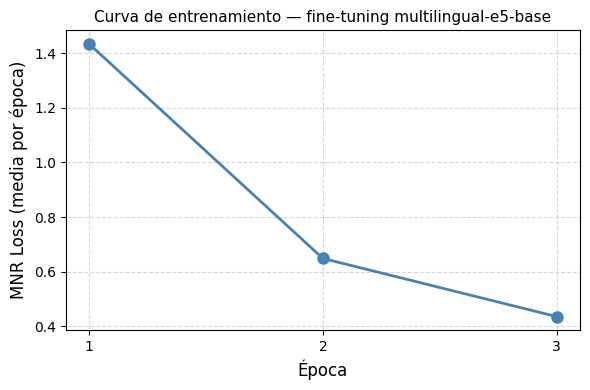

-> Guardada: curva_entrenamiento_e5.png


In [ ]:
# ============================================================
# CELDA ADICIONAL: Re-entrenamiento con curva de pérdida
# ============================================================
import json
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, InputExample, losses

# Semillas para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

class MNRLossTracker(losses.MultipleNegativesRankingLoss):
    """
    Envoltorio sobre MultipleNegativesRankingLoss que, además de calcular
    la pérdida habitual, guarda el valor de cada paso (_step_losses) para
    poder reconstruir la curva de pérdida media por época tras el
    entrenamiento.
    """
    def __init__(self, model):
        """
        Inicializa la pérdida base y la lista donde se acumulará el valor de
        cada paso de entrenamiento.
        """
        super().__init__(model)
        self._step_losses = []

    def forward(self, sentence_features, labels):
        """
        Calcula la pérdida MNR habitual y, además, la registra en
        _step_losses antes de devolverla.
        """
        loss = super().forward(sentence_features, labels)
        self._step_losses.append(loss.item())
        return loss

# Mismos hiperparámetros que el entrenamiento original
_BATCH_SIZE   = 28
_EPOCHS       = 3
_LR           = 2e-5
_MAX_SEQ_LEN  = 512
_MODELO_BASE  = 'intfloat/multilingual-e5-base'
_RUTA_SALIDA  = './modelo_especializado_e5'
_DATASET      = 'dataset_train_triplets.json'

modelo_ft = SentenceTransformer(_MODELO_BASE)
modelo_ft.max_seq_length = _MAX_SEQ_LEN

with open(_DATASET, 'r', encoding='utf-8') as f:
    datos = json.load(f)

ejemplos = [
    InputExample(texts=[
        f"query: {item['pregunta']}",
        f"passage: {item['positiva']}",
        f"passage: {item['negativa']}"
    ])
    for item in datos
]

train_dl   = DataLoader(ejemplos, shuffle=True, batch_size=_BATCH_SIZE)
train_loss = MNRLossTracker(model=modelo_ft)
steps_ep   = len(train_dl)

modelo_ft.fit(
    train_objectives=[(train_dl, train_loss)],
    epochs=_EPOCHS,
    warmup_steps=int(steps_ep * 0.1),
    optimizer_params={'lr': _LR},
    output_path=_RUTA_SALIDA,
    show_progress_bar=True,
)

# Pérdida media por época
all_losses   = train_loss._step_losses
epoch_losses = [
    np.mean(all_losses[i * steps_ep : (i + 1) * steps_ep])
    for i in range(_EPOCHS)
]
print("Pérdida media por época:", epoch_losses)

# Gráfica
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, _EPOCHS + 1), epoch_losses, marker='o', linewidth=2,
        color='steelblue', markersize=8)
ax.set_xlabel('Época', fontsize=12)
ax.set_ylabel('MNR Loss (media por época)', fontsize=12)
ax.set_title('Curva de entrenamiento — fine-tuning multilingual-e5-base', fontsize=11)
ax.set_xticks(range(1, _EPOCHS + 1))
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('curva_entrenamiento_e5.png', dpi=150)
plt.show()
print("-> Guardada: curva_entrenamiento_e5.png")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Calculando similitudes con modelo base...
Calculando similitudes con modelo fine-tuneado...


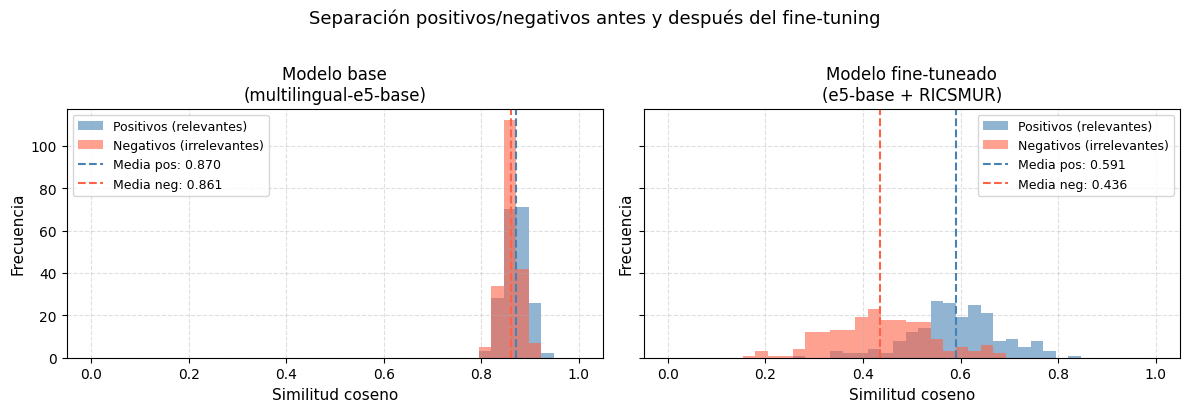

-> Guardada: similitudes_antes_despues_ft.png


In [ ]:
# ============================================================
# CELDA ADICIONAL: Similitud coseno antes vs después fine-tuning
# ============================================================
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import numpy as np
import json

with open('dataset_train_triplets.json', 'r', encoding='utf-8') as f:
    datos = json.load(f)

# Muestra representativa (200 ejemplos para velocidad)
rng     = np.random.default_rng(42)
indices = rng.choice(len(datos), size=min(200, len(datos)), replace=False)
muestra = [datos[i] for i in indices]

queries    = [f"query: {d['pregunta']}"   for d in muestra]
positivos  = [f"passage: {d['positiva']}" for d in muestra]
negativos  = [f"passage: {d['negativa']}" for d in muestra]

modelo_base = SentenceTransformer('intfloat/multilingual-e5-base')
modelo_ft2  = SentenceTransformer('./modelo_especializado_e5')

def calcular_sims(modelo, queries, docs_pos, docs_neg):
    """
    Calcula, para el modelo de embeddings dado, la similitud coseno de cada
    pregunta con su pasaje positivo y con su pasaje negativo, devolviendo
    ambos arrays de similitudes.
    """
    eq  = modelo.encode(queries,   batch_size=32, show_progress_bar=False)
    ep  = modelo.encode(docs_pos,  batch_size=32, show_progress_bar=False)
    en  = modelo.encode(docs_neg,  batch_size=32, show_progress_bar=False)
    sims_pos = [cosine_similarity([eq[i]], [ep[i]])[0][0] for i in range(len(eq))]
    sims_neg = [cosine_similarity([eq[i]], [en[i]])[0][0] for i in range(len(eq))]
    return np.array(sims_pos), np.array(sims_neg)

print("Calculando similitudes con modelo base...")
sims_base_pos, sims_base_neg = calcular_sims(modelo_base, queries, positivos, negativos)

print("Calculando similitudes con modelo fine-tuneado...")
sims_ft_pos, sims_ft_neg = calcular_sims(modelo_ft2, queries, positivos, negativos)

# ── Figura con dos subplots ──────────────────────────────────────────────────
bins = np.linspace(0, 1, 40)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, spos, sneg, titulo in zip(
    axes,
    [sims_base_pos, sims_ft_pos],
    [sims_base_neg, sims_ft_neg],
    ['Modelo base\n(multilingual-e5-base)', 'Modelo fine-tuneado\n(e5-base + RICSMUR)']
):
    ax.hist(spos, bins=bins, alpha=0.6, color='steelblue', label='Positivos (relevantes)')
    ax.hist(sneg, bins=bins, alpha=0.6, color='tomato',    label='Negativos (irrelevantes)')
    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel('Similitud coseno', fontsize=11)
    ax.set_ylabel('Frecuencia', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

    # Líneas de media
    ax.axvline(spos.mean(), color='steelblue', linestyle='--', linewidth=1.5,
               label=f'Media pos: {spos.mean():.3f}')
    ax.axvline(sneg.mean(), color='tomato',    linestyle='--', linewidth=1.5,
               label=f'Media neg: {sneg.mean():.3f}')
    ax.legend(fontsize=9)

plt.suptitle('Separación positivos/negativos antes y después del fine-tuning',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('similitudes_antes_despues_ft.png', dpi=150, bbox_inches='tight')
plt.show()
print("-> Guardada: similitudes_antes_despues_ft.png")
